# Part 3 — Adversarial Attacks: Breaking the Classifier
Implement two adversarial attacks from scratch:
1. Character-level evasion attack
2. Label-flipping poisoning attack

In [5]:
import os, random, warnings, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "aif360", "fairlearn"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, Dataset as TorchDataset
from datasets import Dataset
from transformers import TrainingArguments, Trainer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = "/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/part1_model"
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 64
THRESHOLD  = 0.4

print(f"Device: {DEVICE}")

Device: cuda


In [6]:
# ── Load eval set and train set ──
eval_df  = pd.read_csv("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_df.csv")
train_df = pd.read_csv("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/train_df.csv")

eval_df["label"]  = (eval_df["toxic"] >= 0.5).astype(int)
train_df["label"] = (train_df["toxic"] >= 0.5).astype(int)

print(f"Eval set : {len(eval_df):,} rows")
print(f"Train set: {len(train_df):,} rows")

Eval set : 20,000 rows
Train set: 100,000 rows


In [7]:
# ── Load Part 1 model ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()
print("Part 1 model loaded.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Part 1 model loaded.


In [8]:
def get_probs(texts, batch_size=BATCH_SIZE):
    """Run inference on a list of texts, return numpy array of toxic probabilities."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc   = tokenizer(batch, max_length=MAX_LENGTH, truncation=True,
                          padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.append(probs)
    return np.concatenate(all_probs)

## Attack 1 — Character-Level Evasion

### 1a. The `perturb()` function
Applies three transformations simultaneously:
- **Zero-width space insertion** (U+200B) between every 2–3 chars of words ≥ 4 chars
- **Unicode homoglyph substitution** (Cyrillic lookalikes for a, e, o)
- **Random character duplication** (20% of characters per word)

In [9]:
# Homoglyph map: Latin → Cyrillic visually identical characters
HOMOGLYPHS = {
    'a': '\u0430',   # Cyrillic а
    'e': '\u0435',   # Cyrillic е
    'o': '\u043e',   # Cyrillic о
}

def perturb(text: str) -> str:
    """
    Apply all three character-level perturbations to input text.
    Returns perturbed string that looks identical to humans but
    breaks subword tokenization the model relies on.
    """
    words = text.split()
    perturbed_words = []

    for word in words:
        # Step 1: Unicode homoglyph substitution
        word = "".join(HOMOGLYPHS.get(ch, ch) for ch in word)

        # Step 2: Random character duplication (20% of chars)
        new_word = []
        for ch in word:
            new_word.append(ch)
            if random.random() < 0.20:
                new_word.append(ch)   # duplicate
        word = "".join(new_word)

        # Step 3: Zero-width space insertion between every 2–3 chars
        # only for words >= 4 chars (to meaningfully split subword tokens)
        if len(word) >= 4:
            step = random.choice([2, 3])
            word = "\u200b".join(
                word[j : j + step] for j in range(0, len(word), step)
            )

        perturbed_words.append(word)

    return " ".join(perturbed_words)

# Quick sanity check
sample = "You are a hateful idiot and I hate you"
print("Original  :", sample)
print("Perturbed :", perturb(sample))
print("(Perturbed text contains invisible Unicode — looks similar but tokenizes differently)")

Original  : You are a hateful idiot and I hate you
Perturbed : Yо​оu аа​rr​е а hhа​аtе​ful idi​ооt аnn​d II hа​tе yоu
(Perturbed text contains invisible Unicode — looks similar but tokenizes differently)


In [10]:
# ── Evaluation procedure ──
# Sample 500 comments the clean model predicts as toxic with confidence >= 0.7
eval_probs_clean = np.load("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_probs.npy")
eval_df["clean_prob"] = eval_probs_clean

high_conf_toxic = eval_df[
    (eval_df["clean_prob"] >= 0.7) & (eval_df["label"] == 1)
].sample(n=min(500, ((eval_df["clean_prob"] >= 0.7) & (eval_df["label"] == 1)).sum()),
         random_state=SEED)

print(f"High-confidence toxic comments sampled: {len(high_conf_toxic)}")
print(f"Average clean confidence: {high_conf_toxic['clean_prob'].mean():.4f}")

High-confidence toxic comments sampled: 500
Average clean confidence: 0.9127


In [11]:
# Apply perturbation
original_texts   = high_conf_toxic["comment_text"].tolist()
perturbed_texts  = [perturb(t) for t in original_texts]

# Get probabilities before and after
probs_before = high_conf_toxic["clean_prob"].values
probs_after  = get_probs(perturbed_texts)

preds_before = (probs_before >= THRESHOLD).astype(int)
preds_after  = (probs_after  >= THRESHOLD).astype(int)

# Attack Success Rate: fraction that flipped from toxic (1) → non-toxic (0)
ASR = ((preds_before == 1) & (preds_after == 0)).sum() / len(preds_before)

print(f"\n=== Attack 1 — Character-Level Evasion Results ===")
print(f"  Comments attacked          : {len(original_texts)}")
print(f"  Avg confidence BEFORE      : {probs_before.mean():.4f}")
print(f"  Avg confidence AFTER       : {probs_after.mean():.4f}")
print(f"  Confidence drop            : {(probs_before - probs_after).mean():.4f}")
print(f"  Attack Success Rate (ASR)  : {ASR:.4f}  ({ASR*100:.1f}%)")


=== Attack 1 — Character-Level Evasion Results ===
  Comments attacked          : 500
  Avg confidence BEFORE      : 0.9127
  Avg confidence AFTER       : 0.0416
  Confidence drop            : 0.8711
  Attack Success Rate (ASR)  : 0.9660  (96.6%)


In [12]:
# ASR summary table
asr_table = pd.DataFrame({
    "Metric"  : ["Comments Attacked", "Avg Confidence Before",
                 "Avg Confidence After", "Confidence Drop", "Attack Success Rate"],
    "Value"   : [len(original_texts), f"{probs_before.mean():.4f}",
                 f"{probs_after.mean():.4f}",
                 f"{(probs_before - probs_after).mean():.4f}",
                 f"{ASR:.4f} ({ASR*100:.1f}%)"],
})
print("\n" + asr_table.to_string(index=False))


               Metric          Value
    Comments Attacked            500
Avg Confidence Before         0.9127
 Avg Confidence After         0.0416
      Confidence Drop         0.8711
  Attack Success Rate 0.9660 (96.6%)


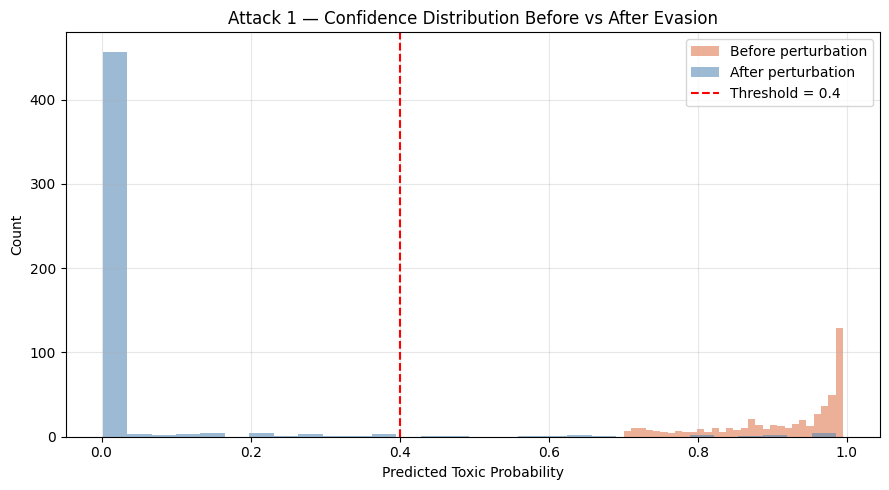

Saved part3_attack1_confidence.png


In [13]:
# Visualise confidence shift
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(probs_before, bins=30, alpha=0.6, label="Before perturbation", color="#E07B54")
ax.hist(probs_after,  bins=30, alpha=0.6, label="After perturbation",  color="#5B8DB8")
ax.axvline(THRESHOLD, color="red", linestyle="--", lw=1.5, label=f"Threshold = {THRESHOLD}")
ax.set_xlabel("Predicted Toxic Probability")
ax.set_ylabel("Count")
ax.set_title("Attack 1 — Confidence Distribution Before vs After Evasion")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/part3_attack1_confidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part3_attack1_confidence.png")

## Attack 2 — Label-Flipping Poisoning

A poisoning attack corrupts the training data before the model is trained.
We randomly flip 5% of labels (toxic → non-toxic and vice versa) and retrain
a fresh DistilBERT from the same pretrained checkpoint.

In [14]:
# ── Poison the training data ──
train_poisoned = train_df.copy()
n_flip = int(0.05 * len(train_poisoned))   # 5% = 5,000 rows

flip_idx = train_poisoned.sample(n=n_flip, random_state=SEED).index
train_poisoned.loc[flip_idx, "label"] = 1 - train_poisoned.loc[flip_idx, "label"]

flipped_to_toxic     = ((train_df.loc[flip_idx, "label"] == 0) &
                         (train_poisoned.loc[flip_idx, "label"] == 1)).sum()
flipped_to_nontoxic  = ((train_df.loc[flip_idx, "label"] == 1) &
                         (train_poisoned.loc[flip_idx, "label"] == 0)).sum()

print(f"Labels flipped        : {n_flip:,}")
print(f"  Non-toxic → Toxic   : {flipped_to_toxic:,}")
print(f"  Toxic → Non-toxic   : {flipped_to_nontoxic:,}")
print(f"\nOriginal  toxic rate  : {train_df['label'].mean():.4f}")
print(f"Poisoned  toxic rate  : {train_poisoned['label'].mean():.4f}")

Labels flipped        : 5,000
  Non-toxic → Toxic   : 4,561
  Toxic → Non-toxic   : 439

Original  toxic rate  : 0.0800
Poisoned  toxic rate  : 0.1212


In [15]:
# ── Tokenize poisoned training set ──
def tokenize(batch):
    return tokenizer(batch["comment_text"], max_length=MAX_LENGTH,
                     truncation=True, padding="max_length")

train_poison_hf = Dataset.from_pandas(train_poisoned[["comment_text", "label"]])
eval_hf         = Dataset.from_pandas(eval_df[["comment_text", "label"]])

print("Tokenizing poisoned training set …")
train_poison_hf = train_poison_hf.map(tokenize, batched=True, batch_size=1000,
                                       remove_columns=["comment_text"])
eval_hf         = eval_hf.map(tokenize, batched=True, batch_size=1000,
                                remove_columns=["comment_text"])

train_poison_hf.set_format("torch", columns=["input_ids", "attention_mask", "label"])
eval_hf.set_format("torch",         columns=["input_ids", "attention_mask", "label"])

Tokenizing poisoned training set …


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [16]:
# ── Retrain from the original pretrained checkpoint (NOT Part 1 fine-tuned model) ──
POISON_MODEL_DIR = "/kaggle/working/part3_poisoned_model"
os.makedirs(POISON_MODEL_DIR, exist_ok=True)

poison_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
poison_model.to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

poison_args = TrainingArguments(
    output_dir                  = POISON_MODEL_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",
)

poison_trainer = Trainer(
    model           = poison_model,
    args            = poison_args,
    train_dataset   = train_poison_hf,
    eval_dataset    = eval_hf,
    compute_metrics = compute_metrics,
)

print("Training poisoned model …")
poison_trainer.train()
print("Poisoned model training complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training poisoned model …


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Poisoned model training complete.


In [18]:
# ── Evaluate poisoned model on the CLEAN eval set ──
poison_preds_out = poison_trainer.predict(eval_hf)
poison_logits    = poison_preds_out.predictions
labels_true      = (eval_df["label"].values)

poison_probs = torch.softmax(torch.tensor(poison_logits), dim=-1).numpy()[:, 1]
poison_preds = (poison_probs >= THRESHOLD).astype(int)

# Clean model metrics (from Part 1 saved probs)
clean_probs  = np.load("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_probs.npy")
clean_preds  = (clean_probs >= THRESHOLD).astype(int)

def get_metrics(y_true, y_pred):
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "F1 Macro" : f1_score(y_true, y_pred, average="macro"),
        "F1 Toxic" : f1_score(y_true, y_pred, pos_label=1),
        "FNR"      : FNR,
        "FP"       : FP, "FN": FN, "TP": TP, "TN": TN,
    }

clean_metrics  = get_metrics(labels_true, clean_preds)
poison_metrics = get_metrics(labels_true, poison_preds)

In [19]:
# ── Before/After comparison table ──
comparison = pd.DataFrame({
    "Metric"        : ["Accuracy", "F1 Macro", "F1 Toxic", "FNR (↑ = worse)"],
    "Clean Model"   : [f"{clean_metrics['Accuracy']:.4f}",
                       f"{clean_metrics['F1 Macro']:.4f}",
                       f"{clean_metrics['F1 Toxic']:.4f}",
                       f"{clean_metrics['FNR']:.4f}"],
    "Poisoned Model": [f"{poison_metrics['Accuracy']:.4f}",
                       f"{poison_metrics['F1 Macro']:.4f}",
                       f"{poison_metrics['F1 Toxic']:.4f}",
                       f"{poison_metrics['FNR']:.4f}"],
    "Change"        : [
        f"{poison_metrics['Accuracy'] - clean_metrics['Accuracy']:+.4f}",
        f"{poison_metrics['F1 Macro'] - clean_metrics['F1 Macro']:+.4f}",
        f"{poison_metrics['F1 Toxic'] - clean_metrics['F1 Toxic']:+.4f}",
        f"{poison_metrics['FNR']      - clean_metrics['FNR']:+.4f}",
    ],
})
print("\n=== Attack 2 — Label-Flipping Poisoning: Before/After ===")
print(comparison.to_string(index=False))


=== Attack 2 — Label-Flipping Poisoning: Before/After ===
         Metric Clean Model Poisoned Model  Change
       Accuracy      0.9395         0.9420 +0.0025
       F1 Macro      0.8085         0.8060 -0.0025
       F1 Toxic      0.6501         0.6435 -0.0066
FNR (↑ = worse)      0.2971         0.3452 +0.0482


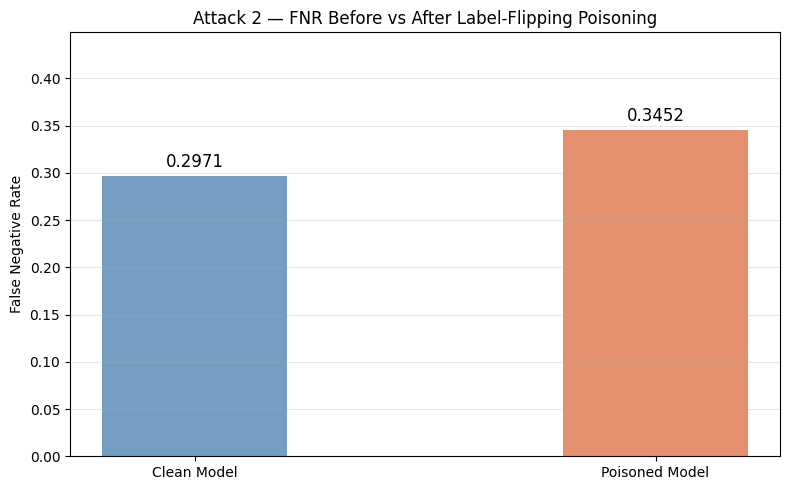

Saved part3_attack2_fnr.png


In [20]:
# Visualise FNR comparison
fig, ax = plt.subplots(figsize=(8, 5))
models  = ["Clean Model", "Poisoned Model"]
fnrs    = [clean_metrics["FNR"], poison_metrics["FNR"]]
colors  = ["#5B8DB8", "#E07B54"]
bars    = ax.bar(models, fnrs, color=colors, width=0.4, alpha=0.85)
for bar, val in zip(bars, fnrs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=12)
ax.set_ylabel("False Negative Rate")
ax.set_title("Attack 2 — FNR Before vs After Label-Flipping Poisoning")
ax.set_ylim(0, max(fnrs) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/part3_attack2_fnr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part3_attack2_fnr.png")

# Save poisoned model probs for reference
np.save("/kaggle/working/poison_probs.npy", poison_probs)

## Key Question — Which Attack is More Operationally Dangerous?
#
**Attack 1 — Character-level evasion** requires the attacker to manually
perturb each comment before posting. It is a per-comment, real-time effort
with no access to the platform's infrastructure. Any technically literate
bad actor could script this, making it low-barrier but high-effort at scale.
Its impact is bounded: each perturbed comment evades detection independently.
#
**Attack 2 — Label-flipping poisoning** requires access to the training
pipeline — either through data contribution (crowdworker manipulation,
coordinated dataset poisoning) or a supply-chain compromise. This is harder
to execute but the damage is systemic: a single poisoning event degrades the
model for every user, permanently, until the model is retrained on clean data.
The elevated FNR means genuinely toxic content now passes moderation at scale
with no per-comment effort from the attacker.
#
**Which threat model is more realistic for a social platform?**
#
The evasion attack is more immediately realistic — bad actors already do this
manually (leetspeak, emoji substitution, deliberate misspellings). The
poisoning attack requires a more sophisticated adversary with pipeline access,
but is not implausible: platforms that crowdsource content labelling or use
open datasets (like Jigsaw) are exposed to coordinated labelling manipulation.
#
**Where should defenses be prioritised?**
#
Short-term: deploy input normalisation (Unicode NFKC normalisation, zero-width
character stripping) as a pre-processing layer — this directly counters Attack 1
at near-zero cost. This is implemented in Part 5's Layer 1 filter.
#
Long-term: invest in training data provenance, label auditing, and anomaly
detection on label distributions before each retraining run. The poisoning
attack is harder to detect after the fact — prevention at the data pipeline
level is the only reliable defense.

In [21]:
print("Part 3 complete.")
print("Files written to /kaggle/working/:")
print("  - part3_attack1_confidence.png")
print("  - part3_attack2_fnr.png")
print("  - poison_probs.npy")
print("  - part3_poisoned_model/")

Part 3 complete.
Files written to /kaggle/working/:
  - part3_attack1_confidence.png
  - part3_attack2_fnr.png
  - poison_probs.npy
  - part3_poisoned_model/
